In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits

### Load and examine SST data

Keep in mind now it has time-coordinate too. 

In [2]:
import os

In [3]:
fname = '/home/milic/data/scratch/nb_6173_2019-05-06T08_33_15_scans=0-170_stokes_corrected_ALIGNED_sp.fcube'

In [4]:
def open_fcube(fname):
    '''
    Open an SST La Palma spectral cube (.fcube) as a memmap.
    The header stores: nlambda as nx, nscans as ny, and ns*nx_im*ny_im as nt.
    Data is written in Fortran (column-major) order, so within the nt axis,
    Stokes index varies fastest: nt_flat = is + ns*(ix + nx_im*iy).

    Returns a dict with metadata and the raw memmap.
    '''
    # --- parse header ---
    h = np.fromfile(fname, dtype='uint8', count=512)
    header = ''.join(chr(c) for c in h[h > 0])
    # find the datatype block (after any extra header separated by ':')
    hd = header[header.lower().find('datatype'):]
    hd = hd.split(':')[0].replace(',', ' ').split()
    
    print(hd)

    typemap = {'1': '<u1', '2': '<i2', '3': '<i4', '4': '<f4'}
    dtype   = typemap[hd[0].split('=')[1]]
    nlambda = int(hd[3].split('=')[1])   # nx in header = nlambda
    nscans  = int(hd[4].split('=')[1])   # ny in header = nscans
    nt_flat = int(hd[5].split('=')[1])   # nt = ns * nx_im * ny_im

    # parse ns from extra-header (e.g. "stokes=[I,Q,U,V], ns=4")
    ns = 1
    if 'ns=' in header:
        ns = int(header.split('ns=')[1].split()[0].rstrip(','))

    # compute spatial dimensions from file size
    itemsize  = np.dtype(dtype).itemsize
    n_floats  = (os.path.getsize(fname) - 512) // itemsize
    n_spatial = n_floats // (nlambda * nscans * ns)
    # find nearest factor pair to a square
    for candidate in range(int(np.sqrt(n_spatial)), 0, -1):
        if n_spatial % candidate == 0:
            nx = candidate
            ny = n_spatial // candidate
            break

    # open memmap with raw (nlambda, nscans, nt_flat) Fortran layout
    raw = np.memmap(fname, dtype=dtype, mode='r', order='F',
                    offset=512, shape=(nlambda, nscans, nt_flat))

    return dict(nlambda=nlambda, nscans=nscans, ns=ns, nx=nx, ny=ny,
                dtype=dtype, header=header, raw=raw)

In [26]:
def open_fcube(fname):
    """
    Open an SST La Palma spectral cube (.fcube) as a memmap.
    True layout in memory (Fortran order, nx varies fastest):
        (nx, ny, ns=4, nt=171, nlambda=15)
    Returns a dict with metadata and the memmap.
    """
    # --- parse header ---
    h = np.fromfile(fname, dtype='uint8', count=512)
    header = ''.join(chr(c) for c in h[h > 0])
    hd = header[header.lower().find('datatype'):]
    hd = hd.split(':')[0].replace(',', ' ').split()

    typemap = {'1': '<u1', '2': '<i2', '3': '<i4', '4': '<f4'}
    dtype   = typemap[hd[0].split('=')[1]]
    nlambda = int(hd[3].split('=')[1])   # nx in header = nlambda
    nt      = int(hd[4].split('=')[1])   # ny in header = nt (nscans)

    ns = 1
    if 'ns=' in header:
        ns = int(header.split('ns=')[1].split()[0].rstrip(','))

    # spatial dims from file size
    itemsize  = np.dtype(dtype).itemsize
    n_floats  = (os.path.getsize(fname) - 512) // itemsize
    n_spatial = n_floats // (nlambda * nt * ns)
    for candidate in range(int(np.sqrt(n_spatial)), 0, -1):
        if n_spatial % candidate == 0:
            nx = candidate
            ny = n_spatial // candidate
            break

    # memmap with true 5D shape (nx, ny, ns, nt, nlambda) — Fortran order
    # so that [:, :, s, t, l] is a contiguous block (fast single read)
    data = np.memmap(fname, dtype=dtype, mode='r', offset=512,
                     #shape=(nx, ny, ns, nt, nlambda), order='F')
                     shape=(nlambda, nt, ns, ny, nx), order = 'F')

    return dict(nx=nx, ny=ny, ns=ns, nt=nt, nlambda=nlambda,
                dtype=dtype, header=header, data=data)


def read_frame(info, lam, scan, stokes):
    """
    Return a single (nx, ny) image.

    Parameters
    ----------
    info   : dict returned by open_fcube()
    lam    : int, wavelength index [0 .. nlambda-1]
    scan   : int, scan/time index  [0 .. nt-1]
    stokes : int, Stokes index     [0=I, 1=Q, 2=U, 3=V]
    """
    #return info['data'][:, :, stokes, scan, lam]
    return info['data'][lam, scan, stokes, :, :]


info = open_fcube(fname)
print(f"nx={info['nx']}, ny={info['ny']}, ns={info['ns']}, "
      f"nt={info['nt']}, nlambda={info['nlambda']}")


nx=1070, ny=1116, ns=4, nt=171, nlambda=15


In [27]:
test = read_frame(info, 2, 21, 0)

In [28]:
test.shape

(1116, 1070)

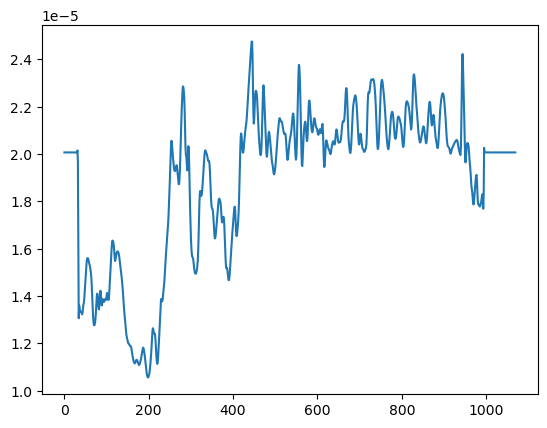

In [30]:
plt.plot(test[222])

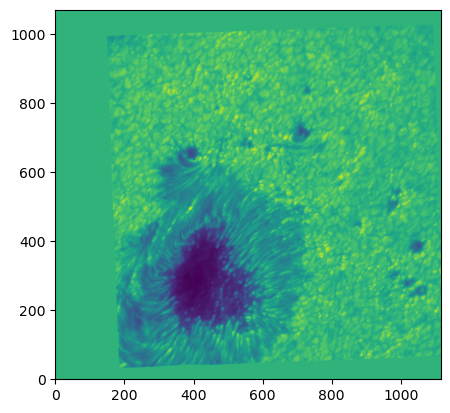

In [31]:
plt.imshow(test.T, origin='lower')